In [2]:
import numpy as np
import pandas as pd

#Load palmer penguins data
url = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(url)

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
#Count non-nas in each column (can also use .info())
penguins.count()


species              344
island               344
bill_length_mm       342
bill_depth_mm        342
flipper_length_mm    342
body_mass_g          342
sex                  333
year                 344
dtype: int64

In [5]:
#Identify the minimum value in each collum with numerical values
penguins.select_dtypes('number').min()

bill_length_mm         32.1
bill_depth_mm          13.1
flipper_length_mm     172.0
body_mass_g          2700.0
year                 2007.0
dtype: float64

## Grouping

`df.groupby(columns_to_group_by).summary_method()`

In [ ]:
#Split data using groupby
# Apply the summary statistic
# Python will return a table of the summary for each group

In [ ]:
#Get the overall mean flipper length using
penguins['flipper_length_mm'].mean()

200.91520467836258

In [7]:
#Get the mean flipper length by species using
penguins.groupby('species')['flipper_length_mm'].mean()

species
Adelie       189.953642
Chinstrap    195.823529
Gentoo       217.186992
Name: flipper_length_mm, dtype: float64

In [8]:
#Save the output as a new dataframe and 
#give the output column a more descriptive name

#Average flipper length per species
avg_flipper = (penguins.groupby('species')                 #Group by species
                        ['flipper_length_mm']              #Call the column of interest
                        .mean()                            #Get the summary statistic
                        .rename('mean_flipper_length')     #Rename the summary stat column
                        .sort_values(ascending = False)    #Sort by descending values
                        )
avg_flipper

species
Gentoo       217.186992
Chinstrap    195.823529
Adelie       189.953642
Name: mean_flipper_length, dtype: float64

In [9]:
#Group using combintations of columns

#Average flipper length per species and island
avg_flipper_species_island = (penguins.groupby(['species', 'island'])
                                ['flipper_length_mm']
                                .mean()
                                .rename('mean_flipper_length')
                                .sort_values(ascending = False)
                                )
avg_flipper_species_island

species    island   
Gentoo     Biscoe       217.186992
Chinstrap  Dream        195.823529
Adelie     Torgersen    191.196078
           Dream        189.732143
           Biscoe       188.795455
Name: mean_flipper_length, dtype: float64

## Grouping and NA values

In [ ]:
#Number of NA observations regarding sex
penguins['sex'].size - penguins['sex'].count()

#Size returns the total observations
#Count returens the number of non-null observations

11

In [ ]:
#Groupby defaluts to leave out the NA values in the grouping column
penguins.groupby('sex').size()

sex
female    165
male      168
dtype: int64

In [12]:
#To keep groupby, use `dropna = False`
penguins.groupby('sex', dropna=False).size()

sex
female    165
male      168
NaN        11
dtype: int64

## Check In

### 1. Idenitfy the number of penguins surveyed on each island in different years

In [13]:
penguins.groupby(['island', 'year']).count()

species  bill_length_mm  bill_depth_mm  flipper_length_mm  \
island    year                                                              
Biscoe    2007       44              44             44                 44   
          2008       64              64             64                 64   
          2009       60              59             59                 59   
Dream     2007       46              46             46                 46   
          2008       34              34             34                 34   
          2009       44              44             44                 44   
Torgersen 2007       20              19             19                 19   
          2008       16              16             16                 16   
          2009       16              16             16                 16   

                body_mass_g  sex  
island    year                    
Biscoe    2007           44   43  
          2008           64   63  
          2009           59   57  
Dream     2007           46   45  
          2008           34   34  
          2009           44   44  
Torgersen 2007           19   15  
          2008           16   16  
          2009           16   16

In [ ]:
penguins.groupby(['island', 'year']).size()

pandas.core.series.Series

Using .count() returns a dataframe of the count of non-null observations for each column since no column of interest was specified.  Using .size() returns a series with the total number of observations for each island/year combination, which is most appropriate for our question.

<Axes: title={'center': 'Penguins surveyed at the Palmer Archipelago'}, xlabel='Number of penguins', ylabel='Island, Year'>

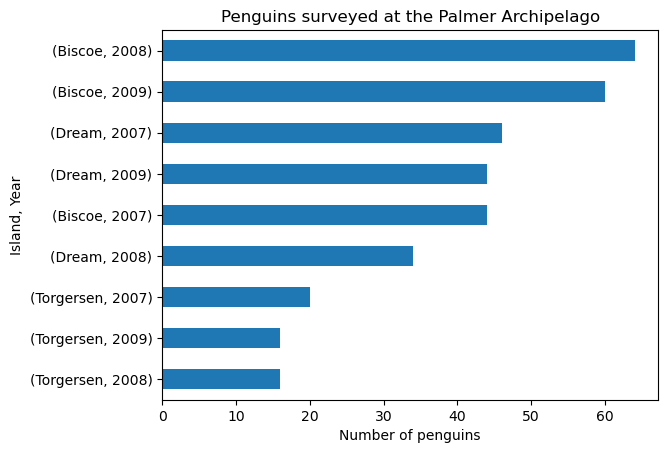

In [19]:
(penguins.groupby(['island', 'year'])
         .size()
         .sort_values()
         .plot(kind = 'barh',
                title = "Penguins surveyed at the Palmer Archipelago",
                xlabel = 'Number of penguins',
                ylabel = 'Island, Year')
        )

## Check-In

In [21]:
mass_year_species = (penguins.groupby(['species', 'year'])
                                ['body_mass_g']
                                .mean()
                                .sort_values())
mass_year_species

species    year
Adelie     2009    3664.903846
Chinstrap  2007    3694.230769
Adelie     2007    3696.428571
Chinstrap  2009    3725.000000
Adelie     2008    3742.000000
Chinstrap  2008    3800.000000
Gentoo     2008    5019.565217
           2007    5070.588235
           2009    5140.697674
Name: body_mass_g, dtype: float64

<Axes: title={'center': 'Penguin body mass at Palmer Archipelago'}, xlabel='Body mass (g)', ylabel='Species, Year'>

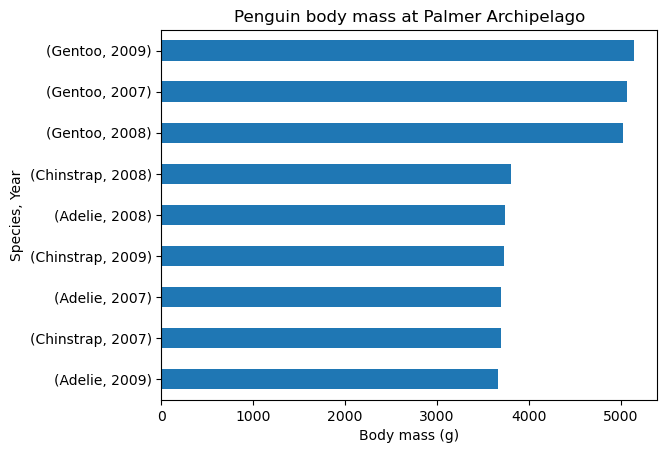

In [23]:
mass_year_species.plot(
        kind = 'barh',
        title = 'Penguin body mass at Palmer Archipelago',
        xlabel = 'Body mass (g)',
        ylabel = 'Species, Year',
)